# Machine learning for regression

In [1]:
import pandas as pd
import numpy as np

## Data preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [8]:
!wget $data

--2026-09-19 17:17:38--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.004s  

2026-09-19 17:17:38 (395 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



## Load data

In [3]:
df = pd.read_csv('data.csv')
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Consistency in column names

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Consistency in content for str
As we did for column names, we apply for the content of those which are str.

In [8]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [12]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## Exploratory data analysis

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

### Looking at price with visualizaton

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### Distribution of prices

<Axes: xlabel='msrp', ylabel='Count'>

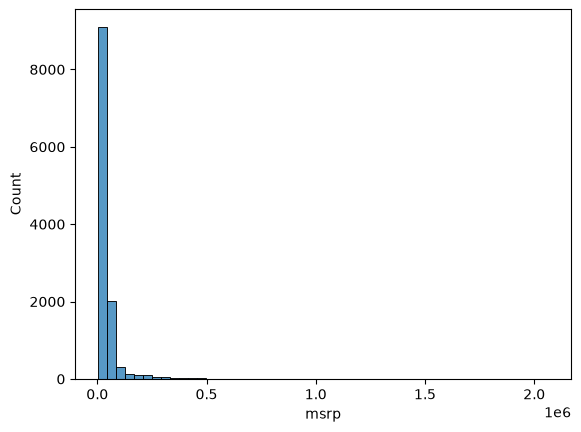

In [15]:
sns.histplot(df['msrp'], bins=50)

#### zoomed in

<Axes: xlabel='msrp', ylabel='Count'>

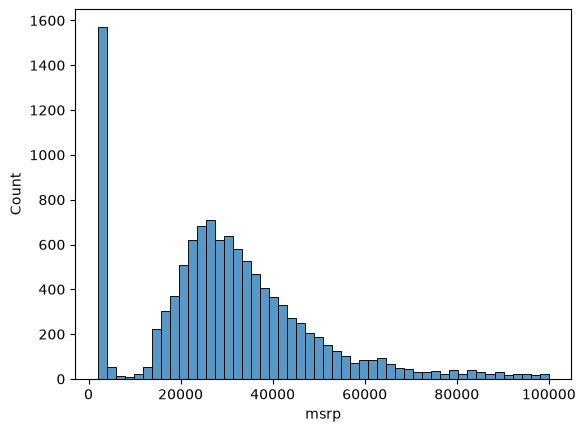

In [16]:
sns.histplot(df['msrp'][df['msrp'] < 100000], bins=50)

In [17]:
np.log1p([1, 10, 1000, 100000]) # same as np.log([0 +1, 1 +1, 10 +1, 1000 +1, 100000 + 1])

array([ 0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [18]:
price_logs = np.log1p(df['msrp'])
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

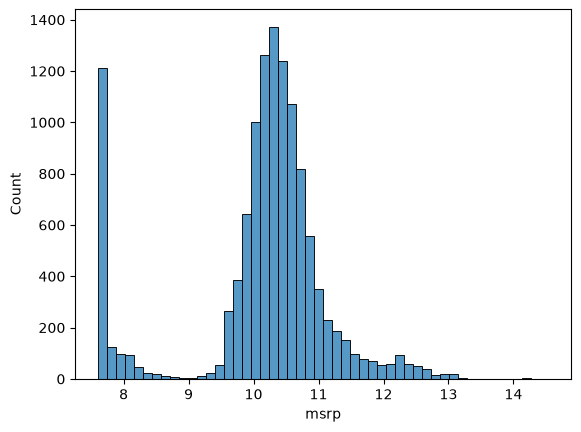

In [19]:
sns.histplot(price_logs, bins=50)
# here it looks more as a normal distribution

# models perform better with normal distributions

### Look at missing values

In [20]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Setting up the validation framework

We will do the 60, 20,20 percent split

In [21]:
int(len(df) * 0.2)

2382

In [22]:
n = len(df)

n_val= int(n *0.2)
n_test = int(n *0.2)
n_train = int(n *0.6)

In [23]:
n, n_val + n_test + n_train
# the rounding is giving a bigger number than the actual size of the dataframe

(11914, 11912)

In [24]:
# For the 60% we do that whatever is out of the n_val and n_test

In [25]:
n = len(df)

n_val= int(n *0.2)
n_test = int(n *0.2)
n_train = n - n_val - n_test

In [26]:
n, n_val + n_test + n_train

(11914, 11914)

In [27]:
# Example (without shuffle)/but we need to shuffle
df_train = df.iloc[n_train:]

df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [28]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


In [29]:
idx = np.arange(n)

In [30]:
np.random.shuffle(idx)

In [31]:
# to make it reproducible
np.random.seed(2)
np.random.shuffle(idx)

In [32]:
idx[n_train:]

array([ 4683, 10235,  9090, ...,   555,  2042, 10474], shape=(4764,))

In [33]:
#shuffle!
df_train = df.iloc[idx[:n_train]]

df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]


In [34]:
df_train.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
8711,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586,32260
5255,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439,34950
6752,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586,19980
304,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774,147332
10519,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210,25145


In [35]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [36]:
df_train= df_train.reset_index(drop=True)
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

In [37]:
df_train.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586,32260
1,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439,34950
2,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586,19980
3,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774,147332
4,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210,25145


In [38]:
y_train = np.log1p(df_train['msrp'].values)
y_val= np.log1p(df_val['msrp'].values)
y_test = np.log1p(df_test['msrp'].values)

In [39]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# delete because we could accidentally use it.

In [40]:
len(y_train)

7150

## Linear regression

In [41]:
df_train.iloc[10]

# we will take 3 characteristics: engine_hp, city_mpg and popularity

make                                       cadillac
model                                           ats
year                                           2016
engine_fuel_type     premium_unleaded_(recommended)
engine_hp                                     272.0
engine_cylinders                                4.0
transmission_type                         automatic
driven_wheels                      rear_wheel_drive
number_of_doors                                 4.0
market_category                  luxury,performance
vehicle_size                                midsize
vehicle_style                                 sedan
highway_mpg                                      31
city_mpg                                         22
popularity                                     1624
Name: 10, dtype: object

In [42]:
xi = [220.0, 24, 3105]

In [43]:
# def g(xi):
#    # do something
#    return 10000

# this is something to implement

In [44]:
w0 = 7.17
w= [0.01,0.04,0.002]

In [45]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [46]:
linear_regression(xi)

16.540000000000003

In [47]:
#np.exp(16.540000000000003)-1
np.expm1(16.540000000000003)

np.float64(15248625.631324615)

## Linear regression vector form

In [48]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [49]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [50]:
w_new = [w0] + w

In [51]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [52]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [53]:
linear_regression(xi)

16.540000000000003

In [54]:
xi = [220.0, 24, 3105]
w0 = 7.17
w= [0.01,0.04,0.002]
w_new = [w0] + w

In [55]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [56]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [57]:
def linear_regression(X):
    return X.dot(w_new)

In [58]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [59]:
# HOW DO WE SET THE VALUES FOR W_NEW? > NEXT LESSON

## Training a linear regression model

In [60]:
#How to find the weights

In [61]:
def train_linear_regression(X, y):
    pass

In [62]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 1385],
    [132, 25, 201],
    [453, 11, 86],
    [148, 54, 1385],
    [132, 25, 2031],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24, 1385],
       [ 132,   25,  201],
       [ 453,   11,   86],
       [ 148,   54, 1385],
       [ 132,   25, 2031],
       [ 453,   31,   86]])

In [63]:
# bias term should be add
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [64]:
X = np.column_stack([ones, X])

In [65]:
## w = (XTX)-1 XT y

In [66]:
y = [100000, 200000, 150000, 250000, 100000, 200000, 150000, 250000, 120000]

In [67]:
XTX = X.T.dot(X)

In [68]:
XTX_inv = np.linalg.inv(XTX)

In [69]:
XTX.dot(XTX_inv) # almost identity matrix (this is fine)

array([[ 1.00000000e+00, -1.78893358e-18,  5.20404867e-17,
        -8.26068882e-19],
       [ 7.62276093e-13,  1.00000000e+00, -3.89375927e-15,
        -1.96983229e-16],
       [-3.92773921e-15, -1.50636339e-16,  1.00000000e+00,
        -1.83144934e-17],
       [ 3.03553840e-13, -5.85496278e-16,  5.16936917e-14,
         1.00000000e+00]])

In [70]:
w_full = XTX_inv.dot(X.T).dot(y)

In [71]:
w_full

array([ 9.42117713e+04,  1.82536273e+02, -1.45055393e+03,  6.94443100e+01])

In [72]:
w0 = w_full[0]
w = w_full[1:]

In [73]:
w0, w
# with negative values, for each extra 'age' for example (- value), the value or price goes down.

(np.float64(94211.77131643405),
 array([  182.53627322, -1450.55392621,    69.44431001]))

In [74]:
### Now we implement this into a function

In [75]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [76]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 1385],
    [132, 25, 201],
    [453, 11, 86],
    [148, 54, 1385],
    [132, 25, 2031],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24, 1385],
       [ 132,   25,  201],
       [ 453,   11,   86],
       [ 148,   54, 1385],
       [ 132,   25, 2031],
       [ 453,   31,   86]])

In [77]:
train_linear_regression(X, y)

(np.float64(94211.77131643405),
 array([  182.53627322, -1450.55392621,    69.44431001]))

## Car price baseline model

In [78]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [79]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [80]:
# extract numerical variables

In [81]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,232.0,NaN,22,16,586
1,348.0,6.0,25,16,1439
2,170.0,4.0,27,21,586
3,400.0,8.0,15,10,2774
4,185.0,6.0,24,17,210
...,...,...,...,...,...
7145,210.0,4.0,27,19,376
7146,125.0,4.0,28,21,1720
7147,170.0,4.0,34,23,873
7148,455.0,8.0,29,17,1385


In [82]:
X_train = df_train[base].values

In [83]:
y_train

array([10.38161435, 10.46170236,  9.9025371 , ..., 10.01864492,
       11.06438583, 10.32223078], shape=(7150,))

In [84]:
train_linear_regression(X_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

In [85]:
df_train[base].isnull().sum()

engine_hp           50
engine_cylinders    18
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [86]:
# we need to do something with missing values

## fill with 0 is the easiest | would mean that we ignore that that variable exist. Not always is the best solution.
df_train[base].fillna(0).isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [87]:
X_train = df_train[base].fillna(0).values

In [88]:
train_linear_regression(X_train, y_train)

(np.float64(7.917971711103474),
 array([ 9.68195445e-03, -1.55041623e-01,  1.59828543e-02,  1.32182247e-02,
        -1.04961169e-05]))

In [89]:
w0, w = train_linear_regression(X_train, y_train)

In [90]:
y_pred = w0 + X_train.dot(w)

In [91]:
y_pred

array([10.72114881, 10.95300116,  9.64670654, ...,  9.78201058,
       11.75660347, 10.41788425], shape=(7150,))

<Axes: ylabel='Count'>

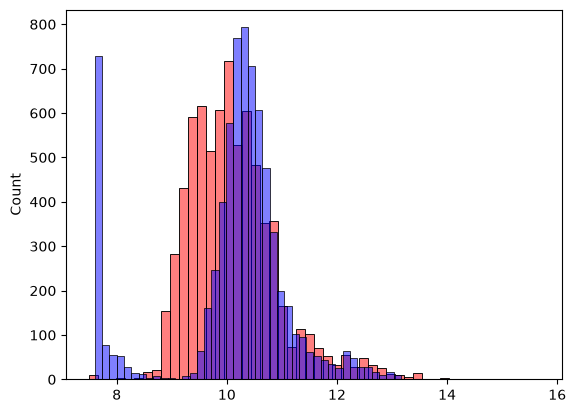

In [92]:
sns.histplot(y_pred, color='red', bins=50, alpha=0.5)
sns.histplot(y_train, color='blue', bins=50, alpha=0.5)

## RMSE (Root Mean Squared Error)

In [93]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [94]:
rmse(y_train, y_pred)

np.float64(0.7557186474297937)

## Validating the model

In [95]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586
1,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439
2,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586
3,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774
4,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,saab,9-3,2009,premium_unleaded_(recommended),210.0,4.0,automatic,front_wheel_drive,2.0,luxury,compact,convertible,27,19,376
7146,kia,sephia,1999,regular_unleaded,125.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,28,21,1720
7147,volkswagen,passat,2017,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,873
7148,chevrolet,corvette,2016,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385


In [96]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [97]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X
    

In [98]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7275323813308997)

## Simple feature engineering

In [99]:
df_train

## look at year, as a feature that is important for price of the car

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586
1,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439
2,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586
3,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774
4,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,saab,9-3,2009,premium_unleaded_(recommended),210.0,4.0,automatic,front_wheel_drive,2.0,luxury,compact,convertible,27,19,376
7146,kia,sephia,1999,regular_unleaded,125.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,28,21,1720
7147,volkswagen,passat,2017,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,873
7148,chevrolet,corvette,2016,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385


In [100]:
df_train.year.max()

np.int64(2017)

In [101]:
2017 - df_train.year

0        6
1        1
2       14
3       13
4        9
        ..
7145     8
7146    18
7147     0
7148     1
7149     1
Name: year, Length: 7150, dtype: int64

In [102]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X
    

In [103]:
# Train
X_train = prepare_X(df_train)


In [104]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5007442216421447)

In [105]:
# big improvement

<Axes: ylabel='Count'>

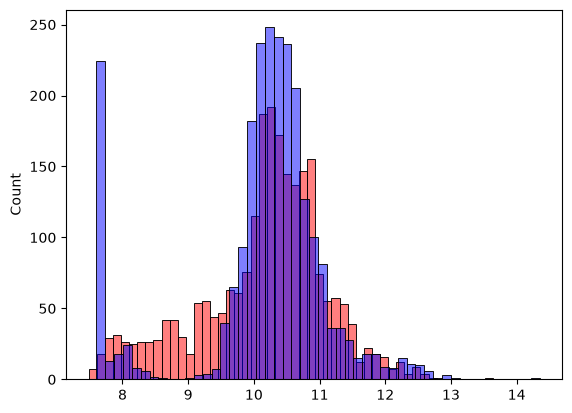

In [106]:
sns.histplot(y_pred, color='red', bins=50, alpha=0.5)
sns.histplot(y_val, color='blue', bins=50, alpha=0.5)

## Categorical variables

In [107]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586
1,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439
2,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586
3,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774
4,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,saab,9-3,2009,premium_unleaded_(recommended),210.0,4.0,automatic,front_wheel_drive,2.0,luxury,compact,convertible,27,19,376
7146,kia,sephia,1999,regular_unleaded,125.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,28,21,1720
7147,volkswagen,passat,2017,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,873
7148,chevrolet,corvette,2016,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385


In [108]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [109]:
#df_train['num_doors_2'] = (df_train.number_of_doors == 2).astype('int')
#df_train['num_doors_3'] = (df_train.number_of_doors == 3).astype('int')
#df_train['num_doors_4'] = (df_train.number_of_doors == 4).astype('int')

In [110]:
#for v in  [2,3,4]:
#    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')


In [111]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,mazda,rx-8,2011,premium_unleaded_(required),232.0,NaN,manual,rear_wheel_drive,4.0,performance,compact,coupe,22,16,586
1,hyundai,genesis_coupe,2016,premium_unleaded_(recommended),348.0,6.0,automatic,rear_wheel_drive,2.0,high-performance,midsize,coupe,25,16,1439
2,mazda,mazdaspeed_protege,2003,premium_unleaded_(required),170.0,4.0,manual,front_wheel_drive,4.0,"factory_tuner,performance",compact,sedan,27,21,586
3,ferrari,360,2004,premium_unleaded_(required),400.0,8.0,manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,coupe,15,10,2774
4,pontiac,torrent,2008,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,crossover,compact,4dr_suv,24,17,210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,saab,9-3,2009,premium_unleaded_(recommended),210.0,4.0,automatic,front_wheel_drive,2.0,luxury,compact,convertible,27,19,376
7146,kia,sephia,1999,regular_unleaded,125.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,28,21,1720
7147,volkswagen,passat,2017,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,873
7148,chevrolet,corvette,2016,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,convertible,29,17,1385


In [112]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [113]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4982452439174593)

In [114]:
# previous result: 0.5216635673736514

In [115]:
makes = list(df.make.value_counts().head().index)

In [116]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [117]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.48795710423269684)

In [118]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [119]:
categorocal_variables = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']

In [120]:
categories = {}

for c in categorocal_variables:
    categories[c] = list(df[c].value_counts().head().index)

categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [121]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [122]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(77.22231280658983)

In [123]:
# as we included too many variables, we made the model worst.

## Regilarization

Controlling the weights so they don't go too big.

The way to do this is: adding a small value to the diagonal of the matrix. The way to do this is the next:

XTX = XTX + 0.01 * np.eye(3)

In [124]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [125]:
# Train
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train)
# Val
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4441362038203576)

## Tuning the model
Finding the best r value

In [126]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score


np.float64(0.4441362038203576)

In [127]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 3.1616936287414196e+16 77.22231280658983
1e-05 7.263079511915832 0.44413723480196704
0.0001 6.438234501021325 0.4441371130039007
0.001 6.4340739135266345 0.4441362038203576
0.1 6.297106859634821 0.44406671761498073
1 5.616147925552326 0.4444274097157417
10 4.290522920617299 0.4558307965739879


## Using the model

In [128]:
### Combine the train and validation dataset to use the model in the test dataset

In [129]:
df_full_train = pd.concat([df_train, df_val])

In [130]:
df_full_train = df_full_train.reset_index(drop=True)

In [131]:
### need to combine as well the y

In [132]:
y_full_train = np.concatenate([y_train, y_val])

In [133]:
### now we prepare the X as we did before

In [134]:
X_full_train = prepare_X(df_full_train)

In [135]:
### now we can train the model on the "full" train dataset

In [136]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [137]:
w0

np.float64(6.382335722925876)

In [138]:
### Now we can use the model in the test dataset

In [139]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

print(w0, score)

6.382335722925876 0.46436169113647763


In [140]:
### Next step would be to use the model to predict the price of a request car model
### We will extract for this lesson a car from the test data set but we need to imagine that
### this would be an input from a person in internet looking for certain characteristics.

In [141]:
car = df_test.iloc[20].to_dict()
car

{'make': 'ford',
 'model': 'taurus',
 'year': 2016,
 'engine_fuel_type': 'premium_unleaded_(recommended)',
 'engine_hp': 365.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'all_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'factory_tuner,high-performance',
 'vehicle_size': 'large',
 'vehicle_style': 'sedan',
 'highway_mpg': 24,
 'city_mpg': 16,
 'popularity': 5657}

In [142]:
# as prepare_X function expect a dataframe, we need to transform the previous dictionary into a dataframe

In [143]:
df_small = pd.DataFrame([car])

In [144]:
X_small = prepare_X(df_small)

In [145]:
X_small

array([[3.650e+02, 6.000e+00, 2.400e+01, 1.600e+01, 5.657e+03, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [146]:
### apply the model

In [147]:
y_pred = w0 + X_val.dot(w)
y_pred

array([ 9.93203226, 10.69552564,  9.7674004 , ..., 10.65615258,
       10.66893495, 10.63116532], shape=(2382,))

In [148]:
y_pred = y_pred[0]

In [149]:
np.expm1(y_pred)

np.float64(20578.120199718047)

In [150]:
## the real price (as we actually know it, but in a real world example we should not)
np.expm1(y_test[20])

np.float64(40275.00000000004)

### Results

In [156]:
# model
w0_full_5_features= w0
score_full_5_features = score
# results
y_real = np.expm1(y_test[20])
y_pred_5_features = np.expm1(y_pred)

In [157]:
w0_full_5_features, score_full_5_features, y_real, y_pred_5_features

(np.float64(6.382335722925876),
 np.float64(0.46436169113647763),
 np.float64(40275.00000000004),
 np.float64(20578.120199718047))

## Expanding features to 10

### Set categories up to 10

In [158]:
categories = {}

for c in categorocal_variables:
    categories[c] = list(df[c].value_counts().head(10).index)

categories

{'make': ['chevrolet',
  'ford',
  'volkswagen',
  'toyota',
  'dodge',
  'nissan',
  'gmc',
  'honda',
  'mazda',
  'cadillac'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel',
  'electric',
  'flex-fuel_(premium_unleaded_required/e85)',
  'flex-fuel_(premium_unleaded_recommended/e85)',
  'flex-fuel_(unleaded/natural_gas)',
  'natural_gas'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback',
  'performance',
  'crossover,luxury',
  'luxury,high-performance',
  'exotic,high-performance',
  'hatchback,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible'

### Adjust prepare_X function for 10 categories

In [159]:
def prepare_X_10(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

### Train the model (with regilarization)
This is using the train dataset. 

In [160]:
# Train
X_train = prepare_X_10(df_train)
w0, w = train_linear_regression_reg(X_train, y_train)
# Val
X_val = prepare_X_10(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.4318847228487267)

Use next the full train and validation datasets as a full train dataset

### Using the model

In [161]:
### Combine the train and validation dataset to use the model in the test dataset

In [162]:
df_full_train = pd.concat([df_train, df_val])

In [163]:
df_full_train = df_full_train.reset_index(drop=True)

In [164]:
### need to combine as well the y

In [165]:
y_full_train = np.concatenate([y_train, y_val])

In [166]:
### now we prepare the X as we did before

In [167]:
X_full_train = prepare_X_10(df_full_train)

In [168]:
### now we can train the model on the "full" train dataset

In [169]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [170]:
w0

np.float64(6.1811078969773625)

#### Use the model in the test dataset

In [171]:
X_test = prepare_X_10(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

print(w0, score)

6.1811078969773625 0.452092637965028


#### Apply the model to test example

In [172]:
### Next step would be to use the model to predict the price of a request car model
### We will extract for this lesson a car from the test data set but we need to imagine that
### this would be an input from a person in internet looking for certain characteristics.

In [173]:
car = df_test.iloc[20].to_dict()
car

{'make': 'ford',
 'model': 'taurus',
 'year': 2016,
 'engine_fuel_type': 'premium_unleaded_(recommended)',
 'engine_hp': 365.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'all_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'factory_tuner,high-performance',
 'vehicle_size': 'large',
 'vehicle_style': 'sedan',
 'highway_mpg': 24,
 'city_mpg': 16,
 'popularity': 5657}

In [174]:
# as prepare_X function expect a dataframe, we need to transform the previous dictionary into a dataframe

In [175]:
df_small = pd.DataFrame([car])

In [176]:
X_small = prepare_X_10(df_small)

In [177]:
X_small

array([[3.650e+02, 6.000e+00, 2.400e+01, 1.600e+01, 5.657e+03, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00]])

In [178]:
### apply the model

In [179]:
y_pred = w0 + X_val.dot(w)
y_pred

array([ 9.91392604, 10.57163701,  9.5943461 , ..., 10.81887717,
       10.5800121 , 10.54156616], shape=(2382,))

In [180]:
y_pred = y_pred[0]

In [181]:
np.expm1(y_pred)

np.float64(20208.863223505596)

In [182]:
## the real price (as we actually know it, but in a real world example we should not)
np.expm1(y_test[20])

np.float64(40275.00000000004)

### Results

In [183]:
# model
w0_full_10_features= w0
score_full_10_features = score
# results
y_real = np.expm1(y_test[20])
y_pred_10_features = np.expm1(y_pred)

In [184]:
w0_full_10_features, score_full_10_features, y_real, y_pred_10_features

(np.float64(6.1811078969773625),
 np.float64(0.452092637965028),
 np.float64(40275.00000000004),
 np.float64(20208.863223505596))

In [185]:
w0_full_5_features, score_full_5_features, y_real, y_pred_5_features

(np.float64(6.382335722925876),
 np.float64(0.46436169113647763),
 np.float64(40275.00000000004),
 np.float64(20578.120199718047))

In [186]:
# RMSE score: If the number goes down, the model got better.
## This means that by increasing the number of features in our model, the prediction for the price gets better.